**TASK 1**

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


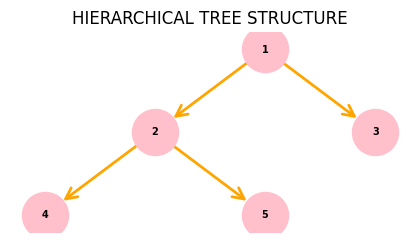

In [3]:
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout
graph ={
    '1':['2','3'],
    '2':['4','5'],
    '3':[],
    '4':[],
    '5':[]
}
G = nx.DiGraph(graph)
plt.figure(figsize=(4,2))
pos = graphviz_layout(G, prog='dot')#dot is use for hierarchical graph
nx.draw(G, pos, with_labels=True,
        node_color ='pink',
        node_size =1100,
        font_size=7,
        font_weight ='bold',
        edge_color ='orange',
        arrowsize=20,
        arrowstyle='->',
        width = 2)
plt.title("HIERARCHICAL TREE STRUCTURE")
plt.show()


**TASK 2**

Processed size: 1000
Processed size: 40000
Processed size: 80000
Processed size: 200000
Processed size: 1000000
   TREE SIZE  BFS TIME  DFS TIME
0       1000  0.000398  0.000365
1      40000  0.025186  0.008279
2      80000  0.053930  0.017707
3     200000  0.062752  0.052603
4    1000000  0.337991  0.306689


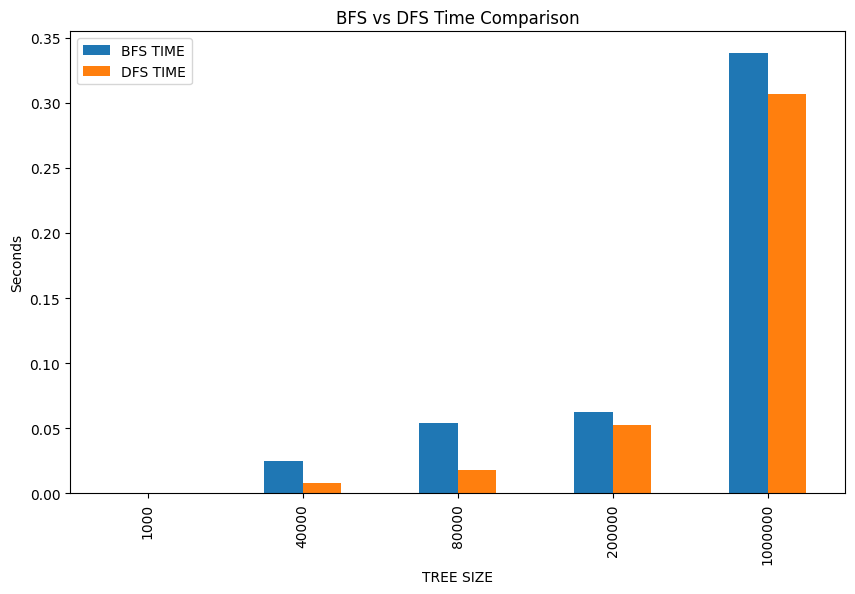

In [17]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
def bfs(data,goal):
  queue = deque([0])
  while queue:
    idx = queue.popleft()
    if idx < len(data):
      if data[idx] == goal:
        return True
      queue.append(2 * idx + 1)
      queue.append(2 * idx + 2)
  return False
def dfs(data,goal):
  stack = [0]
  while stack:
    idx = stack.pop()
    if idx < len(data):
      if data[idx] == goal:
        return True
      # Adding children for DFS
      stack.append(2 * idx + 2)
      stack.append(2 * idx + 1)
  return False
sizes = [1000, 40000, 80000, 200000, 1000000]
results = []
for s in sizes:
  data = random.sample(range(1, s * 10), s)
  goal_index = s - 220
  goal_value = data[goal_index]
  start_time = time.time()
  bfs(data, goal_value)
  bfs_time = time.time() - start_time

  start_time = time.time()
  dfs(data, goal_value)
  dfs_time = time.time() - start_time
  results.append({'TREE SIZE': s, 'BFS TIME': bfs_time, 'DFS TIME': dfs_time})
  print(f"Processed size: {s}")
df = pd.DataFrame(results)
print(df)

df.plot(x='TREE SIZE', y=['BFS TIME', 'DFS TIME'], kind='bar', figsize=(10,6))
plt.ylabel('Seconds')
plt.title('BFS vs DFS Time Comparison')
plt.show()

**TASK 3**

THE SHORTEST PATH IS:['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']


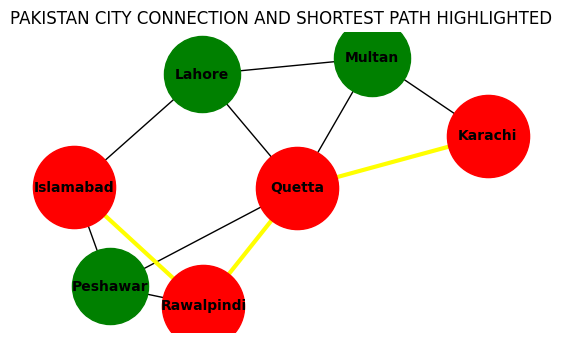

In [24]:
import networkx
import matplotlib.pyplot as plt
graph ={
    'Islamabad':['Rawalpindi','Lahore','Peshawar'],
    'Rawalpindi': ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar': ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore': ['Islamabad', 'Multan', 'Quetta'],
    'Multan': ['Lahore', 'Karachi', 'Quetta'],
    'Quetta': ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi': ['Multan', 'Quetta']
}
def bfs_shortest_path(graph, start, goal):
    queue = [[start]]
    visited = set()
    while queue:
      path = queue.pop(0)
      city = path[-1]
      if city == goal:
          return path
      if city not in visited:
       for neighbour in graph.get(city,[]):
        new_path = list(path)
        new_path.append(neighbour)
        queue.append(new_path)
      visited.add(city)
    return None
#RUNNING THE SEARCH
shortest_path = bfs_shortest_path(graph, 'Islamabad','Karachi')
print(f"THE SHORTEST PATH IS:{shortest_path}")
#DRAW THE RESULT
G= networkx.Graph(graph)
plt.figure(figsize=(5,3))
pos = networkx.spring_layout(G,seed=42)
networkx.draw(G, pos, with_labels=True, node_color='green', node_size=3000, font_size=10, font_weight='bold')
# for shortest path ..highlight it
if shortest_path:
        path_edges = list(zip(shortest_path, shortest_path[1:]))
        networkx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='yellow', width=3)
        networkx.draw_networkx_nodes(G,pos, nodelist =shortest_path,node_color='red',node_size=3500)
plt.title("PAKISTAN CITY CONNECTION AND SHORTEST PATH HIGHLIGHTED")
plt.show()